**Generative AI Use**: For the purposes of the assignments, the use of generative AI is subject to the same policies regarding collaboration. Just as with other collaborators, each student must write down the solutions independently of the output of the interaction and the submission should include a note denoting the nature of the collaboration. The use of generative AI tools to substantially complete sections of the assignments is not in line with the spirit of the assignments, and would be a violation of the [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# Softmax Classifier exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the Softmax classifier.
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [1]:
# Run some setup code for this notebook.
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 Data Loading and Preprocessing

In [2]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

/home/user/code/cs231n.github.io/assignments/2026/assignment1/cs231n/data_utils.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


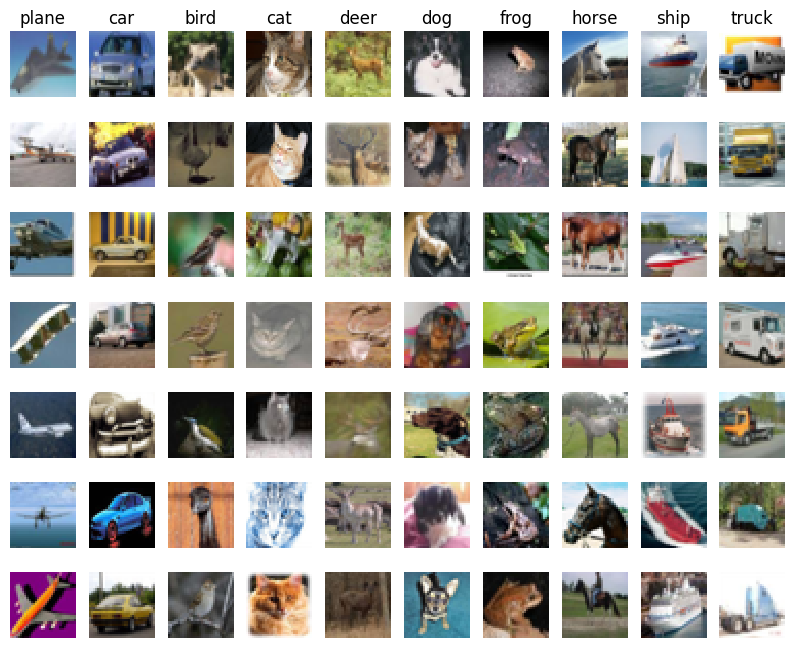

In [3]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [4]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [5]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


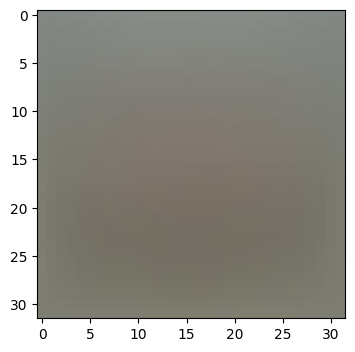

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [6]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# third: append the bias dimension of ones (i.e. bias trick) so that our classifier
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Softmax Classifier

Your code for this section will all be written inside `cs231n/classifiers/softmax.py`.

As you can see, we have prefilled the function `softmax_loss_naive` which uses for loops to evaluate the softmax loss function.

In [7]:
# Evaluate the naive implementation of the loss we provided for you:
from cs231n.classifiers.softmax import softmax_loss_naive
import time

# generate a random Softmax classifier weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.338069
loss: 2.338069
sanity check: 2.302585


In [8]:
W.shape

(3073, 10)

**Inline Question 1**

Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

$\color{blue}{\textit Your Answer:}$ The number of classes is $C=10$. With tiny weights, the cross entropy loss for $z_i$ is
\begin{equation}
L_i = -\log\frac{\exp(z_{y_i})}{\sum_j\exp(z_{y_j})}\approx -\log(\frac{1}{C}) = -\log(0.1)
\end{equation}
Averaging over the loss components gives $\frac{1}{C}\sum L_i = -\log(0.1).$



The `grad` returned from the function above is right now all zero. Derive and implement the gradient for the softmax loss function and implement it inline inside the function `softmax_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

In [9]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Compute the loss and its gradient at W.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 0.637385 analytic: 0.637385, relative error: 4.877094e-08
numerical: -1.373221 analytic: -1.373221, relative error: 4.058058e-08
numerical: 1.527624 analytic: 1.527624, relative error: 2.608940e-09
numerical: 0.783721 analytic: 0.783721, relative error: 1.886156e-08
numerical: -3.212653 analytic: -3.212653, relative error: 7.425928e-09
numerical: -1.053310 analytic: -1.053310, relative error: 2.993964e-08
numerical: -0.040794 analytic: -0.040794, relative error: 2.428918e-07
numerical: 2.017477 analytic: 2.017477, relative error: 1.823275e-08
numerical: -0.170906 analytic: -0.170906, relative error: 2.278417e-08
numerical: 1.434235 analytic: 1.434235, relative error: 5.510542e-08
numerical: -1.492486 analytic: -1.492486, relative error: 1.454462e-08
numerical: -1.467331 analytic: -1.467331, relative error: 1.461902e-10
numerical: 1.314825 analytic: 1.314825, relative error: 9.518172e-09
numerical: 0.673166 analytic: 0.673165, relative error: 1.104889e-07
numerical: 0.828613 

**Inline Question 2**

Although gradcheck is reliable softmax loss, it is possible that for SVM loss, once in a while, a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a svm loss gradient check could fail? How would change the margin affect of the frequency of this happening?

Note that SVM loss for a sample $(x_i, y_i)$ is defined as: $$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$ where $j$ iterates over all classes except the correct class $y_i$ and $s_j$ denotes the classifier score for $j^{th}$ class. $\Delta$ is a scalar margin. For more information, refer to 'Multiclass Support Vector Machine loss' on [this](https://cs231n.github.io/linear-classify/) page.

*Hint: the SVM loss function is not strictly speaking differentiable.*


$\color{blue}{\textit Your Answer:}$ 



In [10]:
y_ex = np.random.randint(0,2,5)
y_ex

array([0, 1, 0, 0, 1])

In [11]:
# definition of SVM loss from the notes
def L_i_vectorized(x, y, W):
  """
  A faster half-vectorized implementation. half-vectorized
  refers to the fact that for a single example the implementation contains
  no for loops, but there is still one loop over the examples (outside this function)
  """
  delta = 1.0
  scores = x.dot(W)
  # compute the margins for all classes in one vector operation
  margins = np.maximum(0, scores - scores[y] + delta)
  # on y-th position scores[y] - scores[y] canceled and gave delta. We want
  # to ignore the y-th position and only consider margin on max wrong class
  margins[y] = 0
  loss_i = np.sum(margins)
  return loss_i

L_i_vectorized(X_dev,y_dev,W)

np.float64(5004.422326338719)

In [12]:
def L(X, y, W):
  """
  fully-vectorized implementation :
  - X holds all the training examples as columns (e.g. 3073 x 50,000 in CIFAR-10)
  - y is array of integers specifying correct class (e.g. 50,000-D array)
  - W are weights (e.g. 10 x 3073)
  """
  scores =  X.dot(W)
  delta = np.ones_like(scores)
  margins = np.maximum(0,scores - scores[y] + delta)
  margins[y] = 0
  loss = margins.sum()
  return loss

L(X_dev,y_dev,W)

np.float64(5004.422326338719)

In [13]:
from cs231n.gradient_check import eval_numerical_gradient_array
f = lambda w: L(X_dev,y_dev,w)
print(f(W))
#eval_numerical_gradient_array(f,W,0.001)[0]

5004.422326338719


In [10]:
# Next implement the function softmax_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 2.338069e+00 computed in 0.050278s
Vectorized loss: 2.338069e+00 computed in 0.025768s
difference: 0.000000


In [11]:
# Complete the implementation of softmax_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.036743s
Vectorized loss and gradient: computed in 0.026689s
difference: 0.000000


### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. Your code for this part will be written inside `cs231n/classifiers/linear_classifier.py`.

In [12]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from cs231n.classifiers import Softmax
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 763.237341
iteration 100 / 1500: loss 280.092774
iteration 200 / 1500: loss 103.642857
iteration 300 / 1500: loss 39.128021
iteration 400 / 1500: loss 15.519504
iteration 500 / 1500: loss 6.878577
iteration 600 / 1500: loss 3.710216
iteration 700 / 1500: loss 2.552754
iteration 800 / 1500: loss 2.107976
iteration 900 / 1500: loss 1.960545
iteration 1000 / 1500: loss 1.919726
iteration 1100 / 1500: loss 1.884331
iteration 1200 / 1500: loss 1.871884
iteration 1300 / 1500: loss 1.880897
iteration 1400 / 1500: loss 1.884212
That took 113.008669s


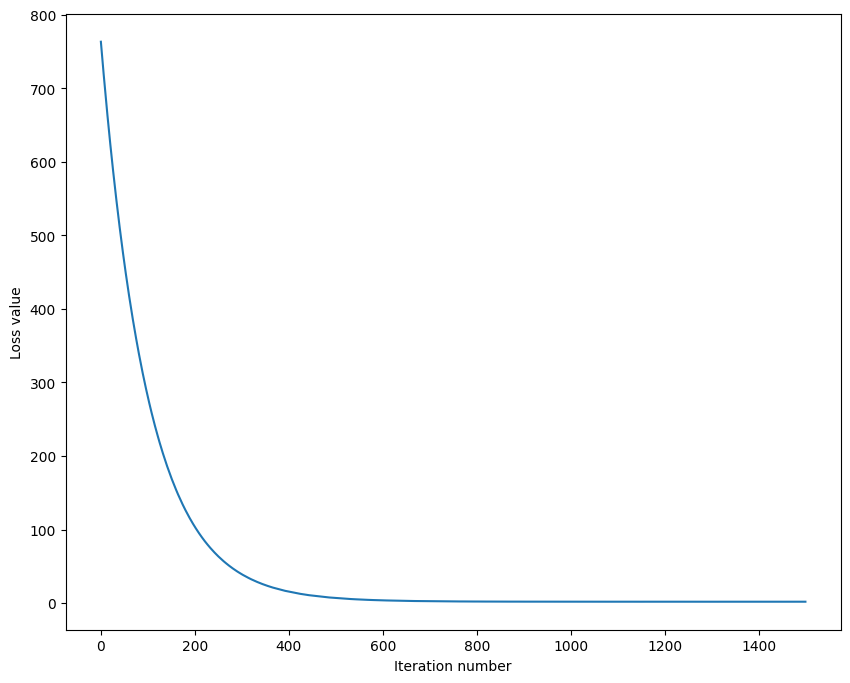

In [13]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [14]:
# Write the LinearClassifier.predict function and evaluate the performance on
# both the training and validation set
# You should get validation accuracy of about 0.34 (> 0.33).
y_train_pred = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.258367
validation accuracy: 0.278000


In [15]:
y_train_pred[0:50]

array([6., 9., 9., 4., 1., 1., 2., 7., 8., 7., 5., 7., 7., 4., 9., 8., 9.,
       3., 2., 6., 2., 3., 6., 6., 6., 6., 6., 5., 4., 9., 1., 9., 1., 4.,
       2., 7., 7., 5., 8., 1., 5., 2., 2., 7., 1., 6., 1., 8., 2., 0.])

In [16]:
# Save the trained model for autograder.
softmax.save("softmax.npy")

softmax.npy saved.


In [23]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of about 0.365 (> 0.36) on the validation set.

# Note: you may see runtime/overflow warnings during hyper-parameter search.
# This may be caused by extreme values, and is not a bug.

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
from cs231n.classifiers import Softmax
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_softmax = None # The Softmax object that achieved the highest validation rate.

################################################################################
# TODO:                                                                        #
# Write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a Softmax on the.        #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the Softmax object that achieves this.   #
# accuracy in best_softmax.                                                    #
#                                                                              #
# Hint: You should use a small value for num_iters as you develop your         #
# validation code so that the classifiers don't take much time to train; once  #
# you are confident that your validation code works, you should rerun the      #
# code with a larger value for num_iters.                                      #
################################################################################

# Provided as a reference. You may or may not want to change these hyperparameter

num_iters = 100
#learning_rates = [1e-7, 1e-6,1e-5,1e-4,1e-3]
learning_rates = np.arange(1e-7,1e-6,1e-7)
regularization_strengths = np.arange(1e4,2.5e4,1e3)
learning_regularization = [(rate,strength) for rate in learning_rates for strength in regularization_strengths]
results = dict.fromkeys(learning_regularization)
results_ = results.copy()
max_iter = len(learning_rates)*len(regularization_strengths)

softmaxes = []
run = 0
param_num=0
print(f"Running algorithm over {len(learning_regularization)} parameters")
for rate,strengths in learning_regularization:
    softmax = Softmax()
    #print(f"Training on rate {rate} and strength {strengths}")
    tic = time.time()
    loss_hist = softmax.train(X_train, y_train, learning_rate=rate, reg=strengths,
                          num_iters=num_iters, verbose=False)
    toc = time.time()
    run += toc-tic
    param_num+=1
    print('That took %fs runtime is %fs, Parameter num %d' % (toc - tic,run,param_num))

    # calculate the accuracies
    y_train_pred = softmax.predict(X_train)
    acc_train = np.mean(y_train==y_train_pred)
    y_val_pred = softmax.predict(X_val)
    acc_pred = np.mean(y_val==y_val_pred)
    # store in results[(r,s)]
    results[(rate,strengths)]=(acc_train,acc_pred)
    results_[(rate,strengths)]=acc_pred
    # store the softmax
    softmaxes.append(softmax)
    softmax.clear()




Running algorithm over 135 parameters
That took 7.025419s runtime is 7.025419s
That took 7.766261s runtime is 14.791680s
That took 7.213589s runtime is 22.005268s
That took 7.080039s runtime is 29.085307s
That took 7.660334s runtime is 36.745642s
That took 7.425744s runtime is 44.171385s
That took 7.276875s runtime is 51.448260s
That took 7.406196s runtime is 58.854457s
That took 7.351399s runtime is 66.205855s
That took 7.448222s runtime is 73.654077s
That took 7.392949s runtime is 81.047026s
That took 7.627337s runtime is 88.674362s
That took 7.911492s runtime is 96.585854s
That took 8.066219s runtime is 104.652073s
That took 8.138000s runtime is 112.790072s
That took 7.960056s runtime is 120.750129s
That took 8.833982s runtime is 129.584111s
That took 8.485661s runtime is 138.069772s
That took 8.195284s runtime is 146.265056s
That took 8.329653s runtime is 154.594709s
That took 9.460062s runtime is 164.054771s
That took 10.458244s runtime is 174.513014s
That took 8.644560s runtime i

In [25]:
# Print out results.
vals = [] 
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    vals.append(val_accuracy)
    # record the validation accuracy
    #softmaxes[(lr,reg)].append(train_accuracy,val_accuracy)
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
sorted_vals=sorted(vals)
best_val = sorted_vals[-1]
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr,reg)]
    if val_accuracy == best_val:
        idx = vals.index(best_val)
        best_softmax = softmaxes[idx]

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 1.000000e+04 train accuracy: 0.125857 val accuracy: 0.119000
lr 1.000000e-07 reg 1.100000e+04 train accuracy: 0.151694 val accuracy: 0.148000
lr 1.000000e-07 reg 1.200000e+04 train accuracy: 0.149286 val accuracy: 0.155000
lr 1.000000e-07 reg 1.300000e+04 train accuracy: 0.141102 val accuracy: 0.123000
lr 1.000000e-07 reg 1.400000e+04 train accuracy: 0.155000 val accuracy: 0.154000
lr 1.000000e-07 reg 1.500000e+04 train accuracy: 0.125245 val accuracy: 0.134000
lr 1.000000e-07 reg 1.600000e+04 train accuracy: 0.127735 val accuracy: 0.112000
lr 1.000000e-07 reg 1.700000e+04 train accuracy: 0.116429 val accuracy: 0.125000
lr 1.000000e-07 reg 1.800000e+04 train accuracy: 0.142571 val accuracy: 0.139000
lr 1.000000e-07 reg 1.900000e+04 train accuracy: 0.132592 val accuracy: 0.143000
lr 1.000000e-07 reg 2.000000e+04 train accuracy: 0.157245 val accuracy: 0.168000
lr 1.000000e-07 reg 2.100000e+04 train accuracy: 0.122857 val accuracy: 0.116000
lr 1.000000e-07 reg 2.200000

In [28]:
win_lr=8e-07
win_rg= 2.4e+04 

In [33]:
softmax=Softmax()
loss_hist = softmax.train(X_train, y_train, learning_rate=win_lr, reg=win_rg, num_iters=1000, verbose=True)

iteration 0 / 1000: loss 740.835277
iteration 100 / 1000: loss 2.169625
iteration 200 / 1000: loss 1.870243
iteration 300 / 1000: loss 1.875802
iteration 400 / 1000: loss 1.875604
iteration 500 / 1000: loss 1.862691
iteration 600 / 1000: loss 1.871903
iteration 700 / 1000: loss 1.872110
iteration 800 / 1000: loss 1.858200
iteration 900 / 1000: loss 1.867047


In [34]:
y_val_pred = softmax.predict(X_val)
acc_pred = np.mean(y_val==y_val_pred)
print(acc_pred)

0.281


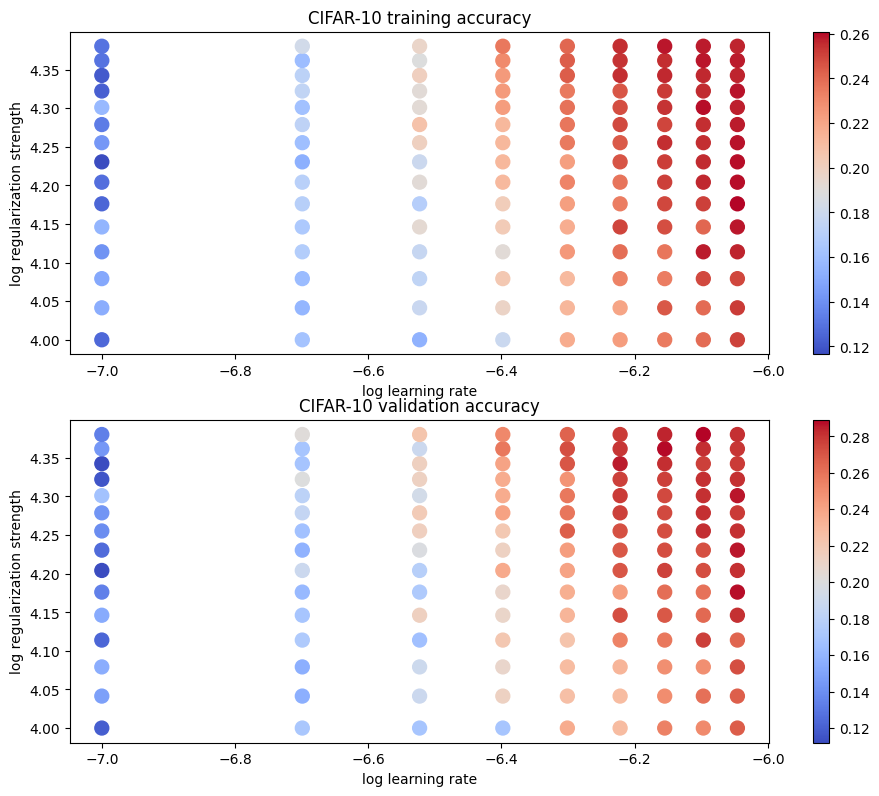

In [26]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [36]:
## refine grid search
num_iters = 100
#learning_rates = [1e-7, 1e-6,1e-5,1e-4,1e-3]
learning_rates = np.arange(1e-6,1e-5,1e-6)
regularization_strengths = np.arange(1e4,2.5e4,1e3)
learning_regularization = [(rate,strength) for rate in learning_rates for strength in regularization_strengths]
results = dict.fromkeys(learning_regularization)
results_ = results.copy()
max_iter = len(learning_rates)*len(regularization_strengths)

softmaxes = []
run = 0
param_num = 0
print(f"Running algorithm over {len(learning_regularization)} parameters")
for rate,strengths in learning_regularization:
    softmax = Softmax()
    #print(f"Training on rate {rate} and strength {strengths}")
    tic = time.time()
    loss_hist = softmax.train(X_train, y_train, learning_rate=rate, reg=strengths,
                          num_iters=num_iters, verbose=False)
    toc = time.time()
    run += toc-tic
    param_num+=1
    print('That took %fs runtime is %fs, Parameter num %d' % (toc - tic,run,param_num))

    # calculate the accuracies
    y_train_pred = softmax.predict(X_train)
    acc_train = np.mean(y_train==y_train_pred)
    y_val_pred = softmax.predict(X_val)
    acc_pred = np.mean(y_val==y_val_pred)
    # store in results[(r,s)]
    results[(rate,strengths)]=(acc_train,acc_pred)
    results_[(rate,strengths)]=acc_pred
    # store the softmax
    softmaxes.append(softmax)
    softmax.clear()

Running algorithm over 135 parameters
That took 7.224622s runtime is 7.224622s, Parameter num 1
That took 7.453387s runtime is 14.678009s, Parameter num 2
That took 8.113264s runtime is 22.791272s, Parameter num 3
That took 8.171917s runtime is 30.963190s, Parameter num 4
That took 8.273277s runtime is 39.236467s, Parameter num 5
That took 8.023612s runtime is 47.260079s, Parameter num 6
That took 9.402731s runtime is 56.662810s, Parameter num 7
That took 7.785385s runtime is 64.448194s, Parameter num 8
That took 7.465548s runtime is 71.913742s, Parameter num 9
That took 8.030629s runtime is 79.944372s, Parameter num 10
That took 7.485399s runtime is 87.429770s, Parameter num 11
That took 7.564796s runtime is 94.994567s, Parameter num 12
That took 7.404456s runtime is 102.399023s, Parameter num 13
That took 7.470205s runtime is 109.869227s, Parameter num 14
That took 7.801483s runtime is 117.670710s, Parameter num 15
That took 7.516026s runtime is 125.186736s, Parameter num 16
That too

In [37]:
# Print out results.
vals = [] 
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    vals.append(val_accuracy)
    # record the validation accuracy
    #softmaxes[(lr,reg)].append(train_accuracy,val_accuracy)
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
sorted_vals=sorted(vals)
best_val = sorted_vals[-1]
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr,reg)]
    if val_accuracy == best_val:
        idx = vals.index(best_val)
        best_softmax = softmaxes[idx]

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-06 reg 1.000000e+04 train accuracy: 0.249776 val accuracy: 0.266000
lr 1.000000e-06 reg 1.100000e+04 train accuracy: 0.257592 val accuracy: 0.280000
lr 1.000000e-06 reg 1.200000e+04 train accuracy: 0.257347 val accuracy: 0.278000
lr 1.000000e-06 reg 1.300000e+04 train accuracy: 0.256796 val accuracy: 0.281000
lr 1.000000e-06 reg 1.400000e+04 train accuracy: 0.259163 val accuracy: 0.284000
lr 1.000000e-06 reg 1.500000e+04 train accuracy: 0.260122 val accuracy: 0.278000
lr 1.000000e-06 reg 1.600000e+04 train accuracy: 0.261735 val accuracy: 0.281000
lr 1.000000e-06 reg 1.700000e+04 train accuracy: 0.258878 val accuracy: 0.290000
lr 1.000000e-06 reg 1.800000e+04 train accuracy: 0.258490 val accuracy: 0.281000
lr 1.000000e-06 reg 1.900000e+04 train accuracy: 0.261980 val accuracy: 0.283000
lr 1.000000e-06 reg 2.000000e+04 train accuracy: 0.258816 val accuracy: 0.281000
lr 1.000000e-06 reg 2.100000e+04 train accuracy: 0.259163 val accuracy: 0.283000
lr 1.000000e-06 reg 2.200000

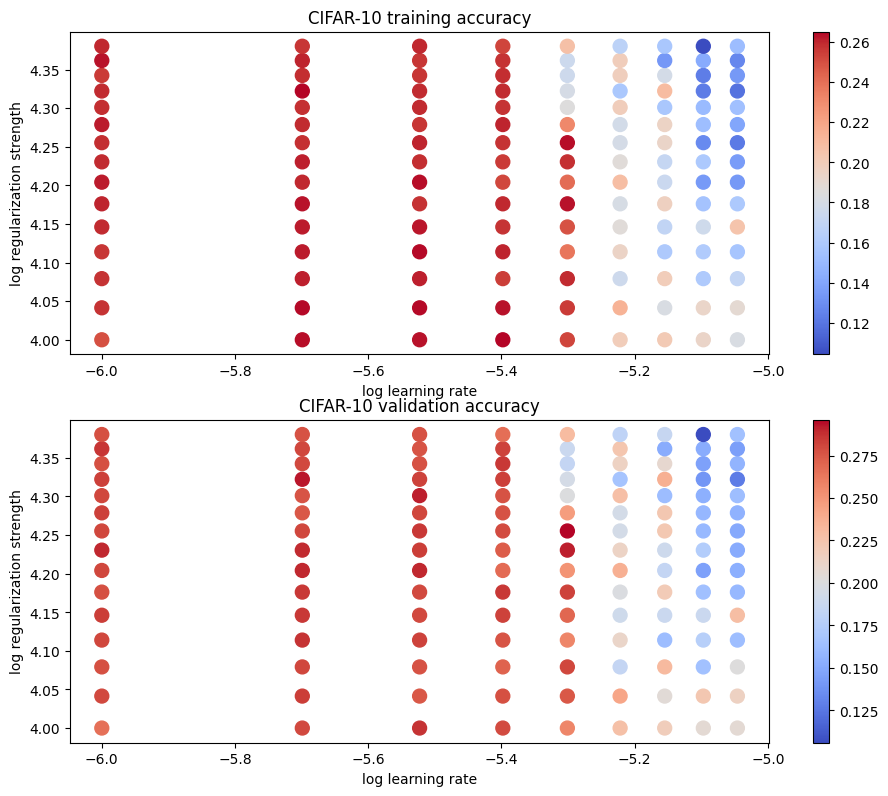

In [38]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [89]:
## refine grid search
num_iters = 250
#learning_rates = [1e-7, 1e-6,1e-5,1e-4,1e-3]
learning_rates = np.arange(0.5*1e-6,0.5*1e-5,1e-6)
regularization_strengths = np.arange(1e4,2.5e4,2*1e3)
learning_regularization = [(rate,strength) for rate in learning_rates for strength in regularization_strengths]
results = dict.fromkeys(learning_regularization)
results_ = results.copy()
max_iter = len(learning_rates)*len(regularization_strengths)

softmaxes = []
run = 0
param_num = 0
print(f"Running algorithm over {len(learning_regularization)} parameters")
for rate,strengths in learning_regularization:
    softmax = Softmax()
    #print(f"Training on rate {rate} and strength {strengths}")
    tic = time.time()
    loss_hist = softmax.train(X_train, y_train, learning_rate=rate, reg=strengths,
                          num_iters=num_iters, verbose=False)
    toc = time.time()
    run += toc-tic
    param_num+=1
    print('That took %fs runtime is %fs, Parameter num %d' % (toc - tic,run,param_num))

    # calculate the accuracies
    y_train_pred = softmax.predict(X_train)
    acc_train = np.mean(y_train==y_train_pred)
    y_val_pred = softmax.predict(X_val)
    acc_pred = np.mean(y_val==y_val_pred)
    # store in results[(r,s)]
    results[(rate,strengths)]=(acc_train,acc_pred)
    results_[(rate,strengths)]=acc_pred
    # store the softmax
    softmaxes.append(softmax)
    softmax.clear()

Running algorithm over 40 parameters
That took 17.447748s runtime is 17.447748s, Parameter num 1
That took 17.509096s runtime is 34.956844s, Parameter num 2
That took 18.131377s runtime is 53.088222s, Parameter num 3
That took 17.259532s runtime is 70.347754s, Parameter num 4
That took 17.781580s runtime is 88.129334s, Parameter num 5
That took 17.992077s runtime is 106.121411s, Parameter num 6
That took 17.396495s runtime is 123.517905s, Parameter num 7
That took 18.119956s runtime is 141.637862s, Parameter num 8
That took 19.006850s runtime is 160.644711s, Parameter num 9
That took 19.826607s runtime is 180.471318s, Parameter num 10
That took 19.221465s runtime is 199.692784s, Parameter num 11
That took 19.658544s runtime is 219.351328s, Parameter num 12
That took 19.479792s runtime is 238.831120s, Parameter num 13
That took 20.037623s runtime is 258.868743s, Parameter num 14
That took 21.910931s runtime is 280.779673s, Parameter num 15
That took 20.076420s runtime is 300.856093s, Pa

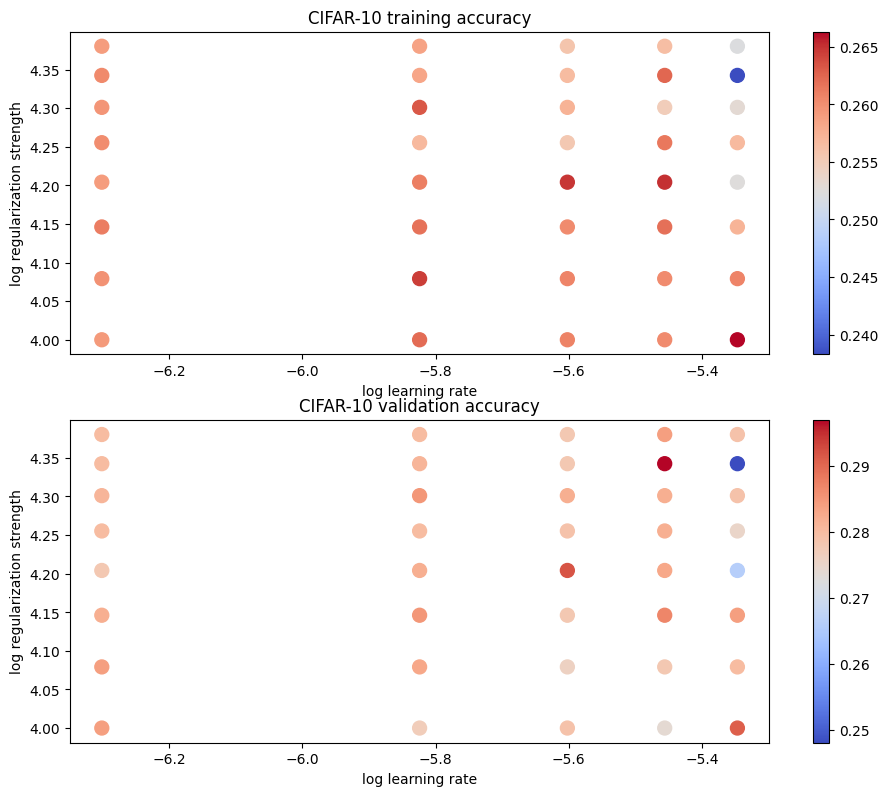

In [90]:
# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [91]:
# Print out results.
vals = [] 
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    vals.append(val_accuracy)
    # record the validation accuracy
    #softmaxes[(lr,reg)].append(train_accuracy,val_accuracy)
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
sorted_vals=sorted(vals)
best_val = sorted_vals[-1]
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr,reg)]
    if val_accuracy == best_val:
        idx = vals.index(best_val)
        best_softmax = softmaxes[idx]

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 5.000000e-07 reg 1.000000e+04 train accuracy: 0.259245 val accuracy: 0.284000
lr 5.000000e-07 reg 1.200000e+04 train accuracy: 0.259816 val accuracy: 0.284000
lr 5.000000e-07 reg 1.400000e+04 train accuracy: 0.261102 val accuracy: 0.282000
lr 5.000000e-07 reg 1.600000e+04 train accuracy: 0.259102 val accuracy: 0.278000
lr 5.000000e-07 reg 1.800000e+04 train accuracy: 0.260102 val accuracy: 0.280000
lr 5.000000e-07 reg 2.000000e+04 train accuracy: 0.259571 val accuracy: 0.281000
lr 5.000000e-07 reg 2.200000e+04 train accuracy: 0.260327 val accuracy: 0.280000
lr 5.000000e-07 reg 2.400000e+04 train accuracy: 0.259000 val accuracy: 0.280000
lr 1.500000e-06 reg 1.000000e+04 train accuracy: 0.262082 val accuracy: 0.277000
lr 1.500000e-06 reg 1.200000e+04 train accuracy: 0.264490 val accuracy: 0.283000
lr 1.500000e-06 reg 1.400000e+04 train accuracy: 0.261714 val accuracy: 0.285000
lr 1.500000e-06 reg 1.600000e+04 train accuracy: 0.260980 val accuracy: 0.282000
lr 1.500000e-06 reg 1.800000

In [92]:
win_lr = 3.5e-6 
win_rg = 2.4e4
softmax=Softmax()
loss_hist = softmax.train(X_train, y_train, learning_rate=win_lr, reg=win_rg, num_iters=500, verbose=True)

iteration 0 / 500: loss 749.608221
iteration 100 / 500: loss 1.868722
iteration 200 / 500: loss 1.862695
iteration 300 / 500: loss 1.871781
iteration 400 / 500: loss 1.875230


In [93]:
y_val_pred = softmax.predict(X_val)
acc_pred = np.mean(y_val==y_val_pred)
print(acc_pred)

0.298


In [77]:
from cs231n.grid_search import refine_grid
test = np.linspace(0,1,10)
test_grid = refine_grid(test,1,5)
test, test_grid

(array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
        0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
 array([0.  , 0.25, 0.5 , 0.75, 1.  ]))

In [88]:
sorted(vals)[-20:]

[np.float64(0.278),
 np.float64(0.278),
 np.float64(0.279),
 np.float64(0.28),
 np.float64(0.28),
 np.float64(0.28),
 np.float64(0.28),
 np.float64(0.281),
 np.float64(0.282),
 np.float64(0.283),
 np.float64(0.284),
 np.float64(0.284),
 np.float64(0.285),
 np.float64(0.285),
 np.float64(0.287),
 np.float64(0.289),
 np.float64(0.289),
 np.float64(0.291),
 np.float64(0.293),
 np.float64(0.3)]

In [20]:
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax classifier on raw pixels final test set accuracy: %f' % test_accuracy)

AttributeError: 'NoneType' object has no attribute 'predict'

In [ ]:
# Save best softmax model
best_softmax.save("best_softmax.npy")

In [ ]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**Inline question 3**

Describe what your visualized Softmax classifier weights look like, and offer a brief explanation for why they look the way they do.

$\color{blue}{\textit Your Answer:}$ *fill this in*  


**Inline Question 4** - *True or False*

Suppose the overall training loss is defined as the sum of the per-datapoint loss over all training examples. It is possible to add a new datapoint to a training set that would change the softmax loss, but leave the SVM loss unchanged.

$\color{blue}{\textit Your Answer:}$


$\color{blue}{\textit Your Explanation:}$

